## Level 2 – Task 3: Clustering Analysis (K-Means)
This task applies K-Means clustering to group similar data points based on feature similarities. The process includes data standardization, determining the optimal number of clusters using the elbow method, and visualizing the resulting clusters.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering & preprocessing
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Load Iris dataset
df = pd.read_csv('/content/1) iris.csv')

# Preview dataset
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Remove target column
X = df.drop('species', axis=1)

X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
# Initialize scaler
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

## Data Standadization
The dataset was standardized using StandardScaler to ensure that all features contribute equally to the clustering process. This prevents features with larger scales from dominating the clustering algorithm.

In [5]:
# List to store inertia values
inertia = []

# Test different values of K
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

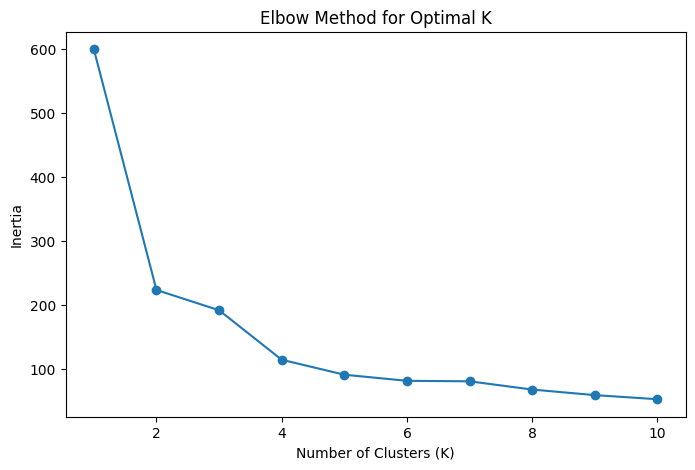

In [6]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

## Elbow Method Insight
The elbow graph shows a steep decrease in inertia from K=1 to K=3, with a continued but smaller decrease at K=4. Beyond this point, the rate of decrease becomes more gradual, indicating diminishing returns. This suggests that the optimal number of clusters lies between 3 and 4. For simplicity and interpretability, K=3 is selected as the optimal number of clusters.

In [7]:
# Apply KMeans with optimal clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit model and predict clusters
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df['Cluster'] = clusters

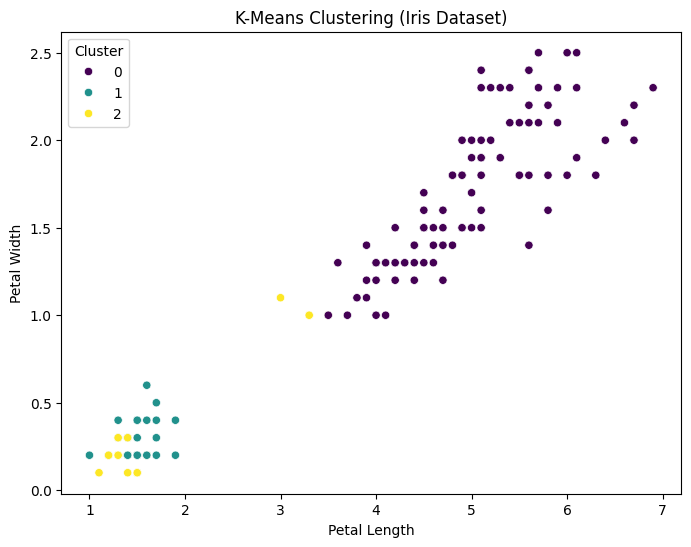

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['petal_length'],
    y=df['petal_width'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title("K-Means Clustering (Iris Dataset)")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.show()

## Cluster Visualization Insight
The scatter plot shows that the data is grouped into three clusters based on petal length and petal width. One cluster is clearly separated and tightly grouped, indicating a distinct set of data points. Another cluster is more spread out but still well-defined, while a few data points appear closer to cluster boundaries, suggesting slight overlap between groups. Overall, the clustering captures the natural structure of the dataset effectively.

## Final Conclusion
K-Means clustering was successfully applied to group the dataset into three clusters based on feature similarities. The elbow method indicated that the optimal number of clusters lies between 3 and 4, with 3 selected for simplicity. The cluster visualization shows that the algorithm effectively identified distinct groups within the data, although some overlap exists between clusters. Overall, the clustering approach provides meaningful insights into the underlying structure of the dataset.